## Importação de Bibliotecas e Carregamento dos Dados

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [5]:
df = pd.read_csv('GlobalFireBurnedArea_2022.csv')

# Converter colunas de data para o formato datetime do pandas
df['Initialdate'] = pd.to_datetime(df['Initialdate'])
df['Finaldate'] = pd.to_datetime(df['Finaldate'])

# Extrair o Mês (1 a 12) da data inicial para a análise temporal
df['Month'] = df['Initialdate'].dt.month

# Calcular a Duração em dias (Final - Inicial)
df['Duration_days'] = (df['Finaldate'] - df['Initialdate']).dt.days

# Limpeza básica: remover linhas onde a duração seja negativa (erro de digitação nos dados)
df = df[df['Duration_days'] >= 0].copy()

print("Dimensões do Dataset após limpeza:", df.shape)
df.head()

Dimensões do Dataset após limpeza: (319278, 11)


,ID,Initialdate,Finaldate,Area_ha,Area_m2,Area_Km2,CountryName,Continent,Region,Month,Duration_days
0,25078590,2022-01-09,2022-02-06,50232.10763,502321076.3,502.321076,Ghana,Africa,Western Africa,1,28
1,25079092,2022-01-11,2022-02-08,82380.29538,823802953.8,823.802954,Nigeria,Africa,Western Africa,1,28
2,25079113,2022-01-11,2022-02-03,36851.12748,368511274.8,368.511275,Nigeria,Africa,Western Africa,1,23
3,25083241,2022-01-03,2022-02-12,43303.63519,433036351.9,433.036352,Nigeria,Africa,Western Africa,1,40
4,25095507,2022-01-01,2022-02-11,75753.14059,757531405.9,757.531406,Central African Republic,Africa,Middle Africa,1,41


## Análise Exploratória Temporal

C:\Users\Augusto\AppData\Local\Temp\ipykernel_16600\2985383302.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fires_per_month.index, y=fires_per_month.values, palette='viridis')
C:\Users\Augusto\AppData\Local\Temp\ipykernel_16600\2985383302.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_per_month.index, y=area_per_month.values, palette='magma')


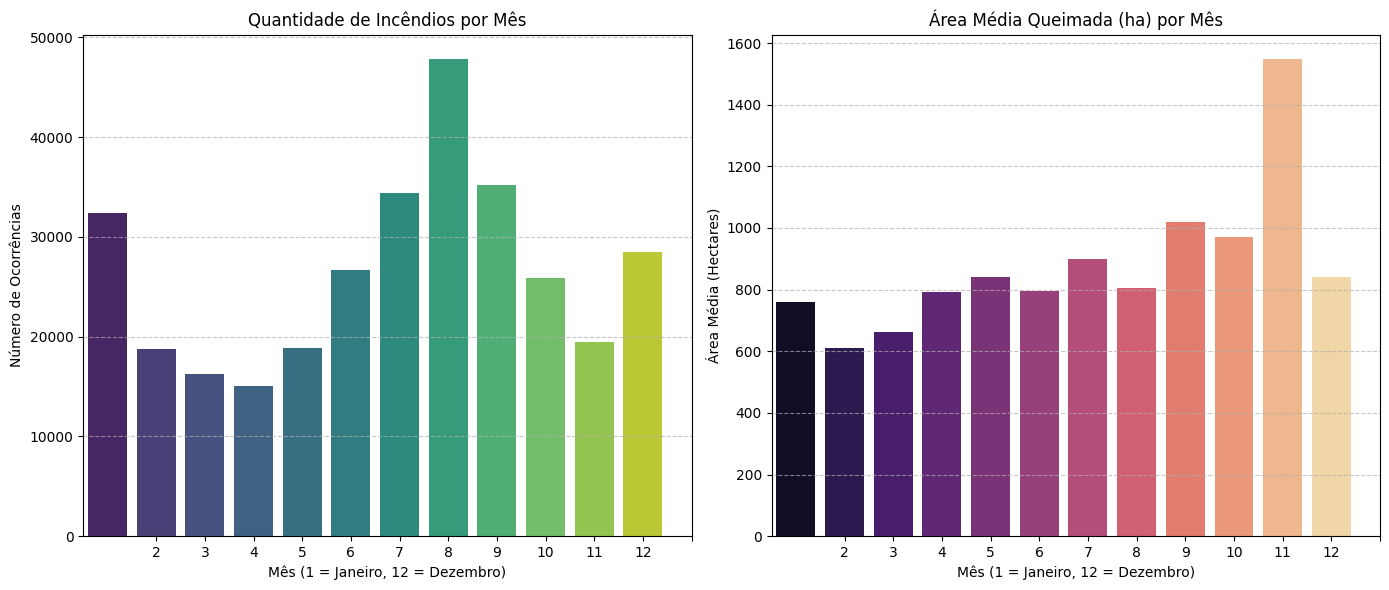

In [6]:
# 2. ANÁLISE EXPLORATÓRIA TEMPORAL (Seus objetivos específicos)

plt.figure(figsize=(14, 6))

# Gráfico 1: Em quais meses acontecem MAIS incêndios (Quantidade)
plt.subplot(1, 2, 1)
fires_per_month = df['Month'].value_counts().sort_index()
sns.barplot(x=fires_per_month.index, y=fires_per_month.values, palette='viridis')
plt.title('Quantidade de Incêndios por Mês')
plt.xlabel('Mês (1 = Janeiro, 12 = Dezembro)')
plt.ylabel('Número de Ocorrências')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico 2: Em quais meses ocorrem os MAIORES incêndios (Área Média em Hectares)
plt.subplot(1, 2, 2)
area_per_month = df.groupby('Month')['Area_ha'].mean()
sns.barplot(x=area_per_month.index, y=area_per_month.values, palette='magma')
plt.title('Área Média Queimada (ha) por Mês')
plt.xlabel('Mês (1 = Janeiro, 12 = Dezembro)')
plt.ylabel('Área Média (Hectares)')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Pré-processamento dos Dados para Machine Learning

In [7]:
# 3. PREPARAÇÃO DOS DADOS PARA O MACHINE LEARNING

# Selecionar as features (variáveis independentes) que vamos usar para prever
# Usamos Month, Duration_days, Continent e Region. 
# (CountryName foi omitido para não criar colunas demais, mas pode ser adicionado se quiser)
features = ['Month', 'Duration_days', 'Continent', 'Region']
X = df[features].copy()

# Variável alvo: Area_ha
y = df['Area_ha'].copy()

# Codificação One-Hot para variáveis categóricas (Continent e Region)
# drop_first=True evita a "armadilha da variável dummy" (multicolinearidade)
X_encoded = pd.get_dummies(X, columns=['Continent', 'Region'], drop_first=True)

# TRANSFORMAÇÃO LOGARÍTMICA NO ALVO (Dica de Ouro para a apresentação!)
# Áreas de incêndio são altamente assimétricas. O logaritmo "achata" a distribuição, 
# impedindo que incêndios gigantescos dominem o erro do modelo.
y_log = np.log1p(y) # log1p é o mesmo que log(1 + x), evita erro com valor 0

# Dividir em dados de Treino (80%) e Teste (20%)
X_train, X_test, y_train_log, y_test_log = train_test_split(X_encoded, y_log, test_size=0.2, random_state=42)

## Treinamento do Modelo

In [8]:
# 4. TREINAMENTO DO MODELO (Random Forest Regressor)

# Inicializar e treinar o modelo
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train_log)

# Fazer previsões no conjunto de teste (ainda em escala logarítmica)
y_pred_log = modelo.predict(X_test)

# REVERTER o logaritmo para obter a área real em hectares (mais fácil de explicar)
y_pred_real = np.expm1(y_pred_log) # expm1 é o inverso de log1p
y_test_real = np.expm1(y_test_log)

# Calcular métricas de erro
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print(f"Erro Absoluto Médio (MAE): {mae:.2f} hectares")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f} hectares")
print(f"Coeficiente de Determinação (R²): {r2:.4f} (Quanto mais perto de 1, melhor)")

Erro Absoluto Médio (MAE): 559.32 hectares
Raiz do Erro Quadrático Médio (RMSE): 6445.92 hectares
Coeficiente de Determinação (R²): 0.0004 (Quanto mais perto de 1, melhor)


## Avaliação do Modelo e Previsão

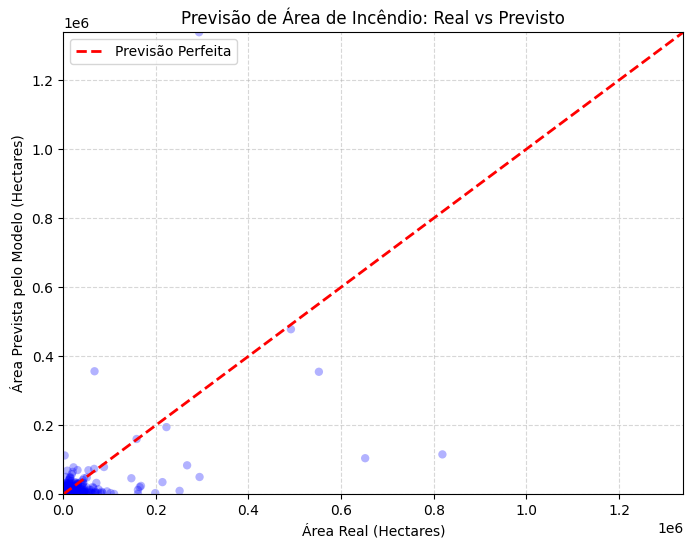

In [9]:
# 5. VISUALIZAÇÃO: REAL vs PREVISTO
plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.3, color='blue', edgecolor='none')

# Linha de previsão perfeita (y = x)
max_val = max(y_test_real.max(), y_pred_real.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Previsão Perfeita')

plt.xlabel('Área Real (Hectares)')
plt.ylabel('Área Prevista pelo Modelo (Hectares)')
plt.title('Previsão de Área de Incêndio: Real vs Previsto')
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Conhecimento Obtido: Importância das Features (Sazonalidade)

C:\Users\Augusto\AppData\Local\Temp\ipykernel_16600\3002950730.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='Blues_r')


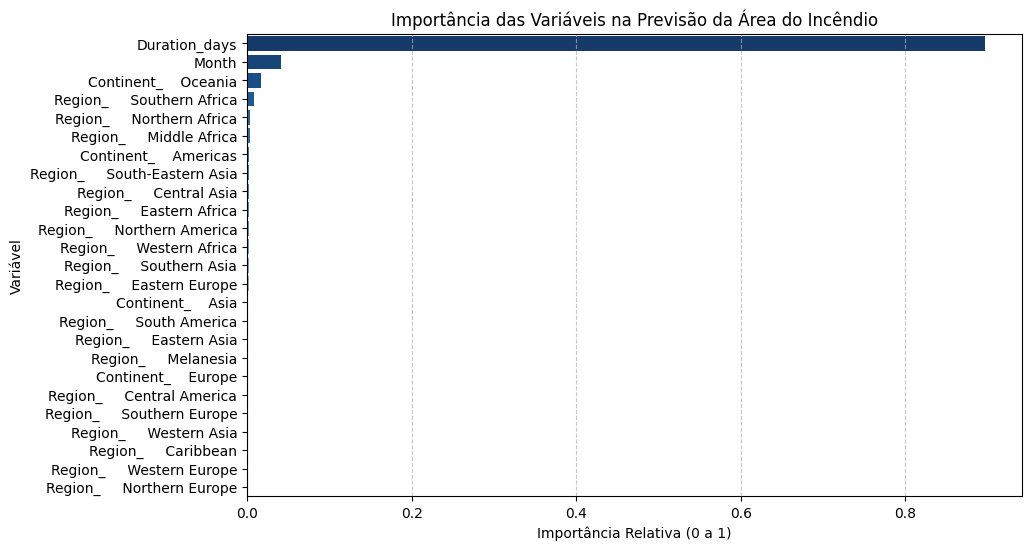


Ranking de Importância das Variáveis:
                           Feature  Importance
1                    Duration_days    0.896760
0                            Month    0.041497
5            Continent_    Oceania    0.017206
19     Region_     Southern Africa    0.008423
14     Region_     Northern Africa    0.003607
13       Region_     Middle Africa    0.003489
2           Continent_    Americas    0.002944
18  Region_     South-Eastern Asia    0.002777
8         Region_     Central Asia    0.002212
9       Region_     Eastern Africa    0.002058


In [10]:
# 6. CONHECIMENTO OBTIDO: IMPORTÂNCIA DAS FEATURES (Sazonalidade)
# Isso prova se o "Mês" realmente foi importante para o modelo prever a área

importances = modelo.feature_importances_
feature_names = X_encoded.columns

# Criar um DataFrame para ordenar e visualizar melhor
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='Blues_r')
plt.title('Importância das Variáveis na Previsão da Área do Incêndio')
plt.xlabel('Importância Relativa (0 a 1)')
plt.ylabel('Variável')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\nRanking de Importância das Variáveis:")
print(df_importance.head(10)) # Mostra as 10 mais importantes